<a href="https://colab.research.google.com/github/harshal8704/NNDL-Practicals/blob/main/NNDL_Prac9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set parameters for the dataset
vocab_size = 10000
max_length = 200

print("Loading IMDB dataset...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"Training sequences: {len(x_train)}")
print(f"Testing sequences: {len(x_test)}")

Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training sequences: 25000
Testing sequences: 25000


In [2]:
print("Padding sequences to a uniform length...")

# Pad the sequences to max_length (200)
x_train_padded = pad_sequences(x_train, maxlen=max_length, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test, maxlen=max_length, padding='post', truncating='post')

print(f"Shape of padded training data: {x_train_padded.shape}")
print(f"Shape of padded testing data: {x_test_padded.shape}")

Padding sequences to a uniform length...
Shape of padded training data: (25000, 200)
Shape of padded testing data: (25000, 200)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Set model dimensions
embedding_dim = 32
rnn_units = 32

print("Building the RNN model...")
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    SimpleRNN(units=rnn_units),
    Dense(units=1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
model.summary()

Building the RNN model...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
print("Training the model...")

history = model.fit(
    x_train_padded,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Training the model...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.5017 - loss: 0.6949 - val_accuracy: 0.5130 - val_loss: 0.6925
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.6084 - loss: 0.6563 - val_accuracy: 0.5190 - val_loss: 0.7013
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.6910 - loss: 0.5420 - val_accuracy: 0.5056 - val_loss: 0.7707
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7544 - loss: 0.4274 - val_accuracy: 0.5026 - val_loss: 0.8851
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.7951 - loss: 0.3563 - val_accuracy: 0.5092 - val_loss: 0.9742


In [5]:
print("Evaluating model on the test set...")
test_loss, test_acc = model.evaluate(x_test_padded, y_test)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Evaluating model on the test set...
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5046 - loss: 0.9675

Final Test Accuracy: 0.5046
Final Test Loss: 0.9675


In [6]:
import numpy as np

# Load the IMDB word dictionary and adjust indices
word_index = imdb.get_word_index()
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2  # Unknown word
word_index["<UNUSED>"] = 3

def predict_sentiment(review_text):
    # Tokenize the input text
    words = review_text.lower().split()
    tokens = [word_index.get(word, 2) for word in words]

    # Pad it exactly like our training data
    padded_tokens = pad_sequences([tokens], maxlen=max_length, padding='post', truncating='post')

    # Predict
    prediction = model.predict(padded_tokens)[0][0]
    sentiment = "Positive" if prediction >= 0.5 else "Negative"

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment} (Score: {prediction:.4f})\n")

# Test with a positive and a negative review
predict_sentiment("This movie was absolutely fantastic I loved it")
predict_sentiment("Terrible movie the acting was awful and boring")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
Review: 'This movie was absolutely fantastic I loved it'
Sentiment: Positive (Score: 0.5305)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Review: 'Terrible movie the acting was awful and boring'
Sentiment: Positive (Score: 0.5492)



In [7]:
from tensorflow.keras.layers import LSTM, Input

print("Fixing data: Pre-padding sequences...")
# Zeros go at the beginning now!
x_train_padded = pad_sequences(x_train, maxlen=max_length, padding='pre', truncating='pre')
x_test_padded = pad_sequences(x_test, maxlen=max_length, padding='pre', truncating='pre')

print("Building the upgraded LSTM model...")
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(units=rnn_units),
    Dense(units=1, activation='sigmoid')
])

# Compile the new model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Fixing data: Pre-padding sequences...
Building the upgraded LSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Training the upgraded LSTM model...")

history_lstm = model.fit(
    x_train_padded,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

Training the upgraded LSTM model...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.7513 - loss: 0.4939 - val_accuracy: 0.8566 - val_loss: 0.3440
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 131ms/step - accuracy: 0.8946 - loss: 0.2653 - val_accuracy: 0.8788 - val_loss: 0.2961
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.9284 - loss: 0.1949 - val_accuracy: 0.8756 - val_loss: 0.3213


In [9]:
print("Evaluating LSTM model on the test set...")
test_loss, test_acc = model.evaluate(x_test_padded, y_test)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print("-" * 30)

# Update our predict function to use 'pre' padding
def predict_sentiment_lstm(review_text):
    words = review_text.lower().split()
    tokens = [word_index.get(word, 2) for word in words]

    # IMPORTANT: Changed to 'pre' padding to match our new training data
    padded_tokens = pad_sequences([tokens], maxlen=max_length, padding='pre', truncating='pre')

    # Predict (verbose=0 just hides the progress bar for single predictions)
    prediction = model.predict(padded_tokens, verbose=0)[0][0]
    sentiment = "Positive" if prediction >= 0.5 else "Negative"

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment} (Score: {prediction:.4f})\n")

print("Testing custom reviews again with the smart model:\n")
predict_sentiment_lstm("This movie was absolutely fantastic I loved it")
predict_sentiment_lstm("Terrible movie the acting was awful and boring")

Evaluating LSTM model on the test set...
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8666 - loss: 0.3422

Final Test Accuracy: 0.8666
------------------------------
Testing custom reviews again with the smart model:

Review: 'This movie was absolutely fantastic I loved it'
Sentiment: Positive (Score: 0.8751)

Review: 'Terrible movie the acting was awful and boring'
Sentiment: Negative (Score: 0.0297)



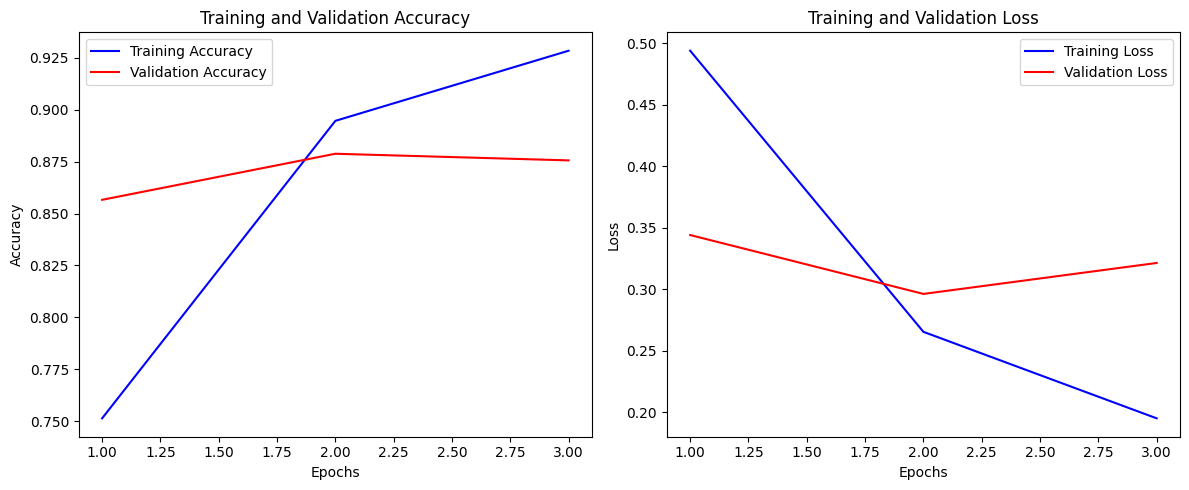

In [10]:
import matplotlib.pyplot as plt

# Extract data from the history object
acc = history_lstm.history['accuracy']
val_acc = history_lstm.history['val_accuracy']
loss = history_lstm.history['loss']
val_loss = history_lstm.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()